In [ ]:
import os
import glob

# =============================================
# Configuration section (usually no need to modify)
# =============================================

# 1. If you want to specify the filename manually, uncomment the line below and change it to your filename
# Example: custom_filename = "my_dataset.zip"
custom_filename = "re_data_TinyStories_cosine_restarts_20k_bs20.zip"

# 2. Target extraction folder (named re_data_Tiny as per your description)
output_dir = "/content/re_data_Tiny"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Target extraction directory: {output_dir}")

# =============================================
# Automatic archive detection
# =============================================

# Prefer the manually specified filename
if custom_filename:
    file_path = f"/content/{custom_filename}"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find the file you specified: {file_path}")
else:
    # Automatically scan for common archive formats
    archives = []
    for ext in ['*.zip', '*.tar.gz', '*.tgz', '*.rar', '*.7z']:
        archives.extend(glob.glob(f"/content/{ext}"))

    # Filter out directories, keep only files
    archives = [f for f in archives if os.path.isfile(f)]

    if not archives:
        print("❌ No archive found in /content/!")
        print(f"📂 Contents of current /content/ directory: {os.listdir('/content/')}")
        print("💡 Please confirm the file has been uploaded via the left sidebar, or set custom_filename above")
        raise FileNotFoundError("No archive detected")
    else:
        file_path = archives[0]  # Take the first one found
        print(f"✅ Automatically detected archive: {file_path}")
        if len(archives) > 1:
            print(f"⚠️ Multiple archives detected, will only process the first one: {file_path}")

# =============================================
# Extract based on file extension
# =============================================

print(f"⏳ Extracting {os.path.basename(file_path)} ...")

if file_path.endswith('.zip'):
    # -q: quiet mode, -d: specify destination directory
    !unzip -q "$file_path" -d "$output_dir"

elif file_path.endswith('.tar.gz') or file_path.endswith('.tgz'):
    # -xzvf shows the extraction process for easy observation
    !tar -xzvf "$file_path" -C "$output_dir"

elif file_path.endswith('.tar'):
    !tar -xvf "$file_path" -C "$output_dir"

elif file_path.endswith('.rar'):
    # Automatically install unrar tool (only needed the first time)
    !apt-get install unrar -y > /dev/null 2>&1
    !unrar x "$file_path" "$output_dir"

elif file_path.endswith('.7z'):
    # Automatically install p7zip tool (only needed the first time)
    !apt-get install p7zip-full -y > /dev/null 2>&1
    !7z x "$file_path" -o"$output_dir"

else:
    print("❌ Unsupported archive format, please handle manually")
    exit()

# =============================================
# Show extraction results
# =============================================

print("\n✅ Extraction complete!")
print(f"📂 File list after extraction (first 20 lines of {output_dir}):")
!ls -lh "$output_dir" | head -20

📁 Target extraction directory: /content/re_data_Tiny
⏳ Extracting re_data_TinyStories_cosine_restarts_20k_bs20.zip ...

✅ Extraction complete!
📂 File list after extraction (first 20 lines of /content/re_data_Tiny):
total 200K
-rw-r--r-- 1 root root 199K Jul 31 16:58 re_data_TinyStories_adam_lr5e-4_cosine_restarts_medium_20k_bs20.npz


Number of data points: 998
Steps range: 40 ~ 19980
Re_old median: 1.196e+00
Re_old mean  : 8.118e+01


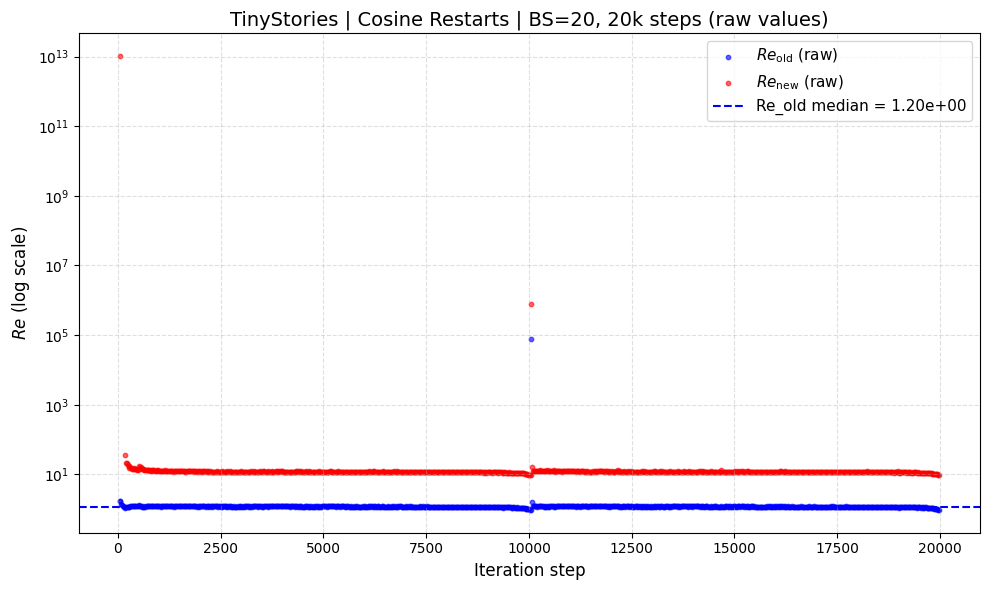

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# 1. Load the data
# =============================================
data = np.load("/content/re_data_Tiny/re_data_TinyStories_adam_lr5e-4_cosine_restarts_medium_20k_bs20.npz")

steps = data["steps"]
re_old_raw = data["Re_old_raw"]
re_new_raw = data["Re_new_raw"]

print(f"Number of data points: {len(steps)}")
print(f"Steps range: {steps.min()} ~ {steps.max()}")

# =============================================
# 2. Compute typical level for Re_old
# =============================================
# You can choose median or mean. Median is more robust.
re_old_median = np.median(re_old_raw)
re_old_mean   = np.mean(re_old_raw)

print(f"Re_old median: {re_old_median:.3e}")
print(f"Re_old mean  : {re_old_mean:.3e}")

# Choose which one to plot (here we use median)
reference_value = re_old_median
# If you prefer the mean, uncomment the next line:
#reference_value = re_old_mean

# =============================================
# 3. Scatter plot of raw values with log y-axis
# =============================================
plt.figure(figsize=(10, 6))

# Raw Re_old values
plt.scatter(steps, re_old_raw, s=10, alpha=0.6, label=r'$Re_{\mathrm{old}}$ (raw)', color='blue')

# Raw Re_new values
plt.scatter(steps, re_new_raw, s=10, alpha=0.6, label=r'$Re_{\mathrm{new}}$ (raw)', color='red')

# Add a horizontal line for Re_old reference level
plt.axhline(y=reference_value, color='blue', linestyle='--', linewidth=1.5,
            label=f'Re_old median = {reference_value:.2e}')

# =============================================
# 4. Axis settings
# =============================================
plt.yscale('log')                    # Log scale for y-axis (base 10)
plt.xlabel("Iteration step", fontsize=12)
plt.ylabel(r'$Re$ (log scale)', fontsize=12)
plt.title("TinyStories | Cosine Restarts | BS=20, 20k steps (raw values)", fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()